# On the failure of MO coefficients: Fock matrix edition
This is another chapter on the location of the issue in discrepancies of MP2 energies. At this point, we have located that the source of error must be on the MO coefficients, particularly in systems where $l\ge 1$ and $n\ge 1$ except when $l=0$, where there is no issues with increasing $n$. 

Before this point, we have located an error and/or contradiction: the resulting MO coefficients obtained directly from the diagonalization of the Fock matrix in the orthogonal representation:
$$
C_{MO} = C_{AO}X
$$
Where $X$ is the transformation matrix (canonical orthogonalization in this case) and:
$$
C_{AO}^T (X^T F_{MO} X) C_{AO} = \varepsilon
$$

The orbitals resulting directingly did not diagonalize the $F_{MO}$, while they should, as we will see now. However, canonicalizing the virtual block, leaded to an order mixing issue and to non degenerate eigenvalues. I thought that this was just an issue with the canonicalization, that it broke the eigenvalue-eigenvector solution, and I suspected that the breaking of degeneracy must have been an artifact of this. 

What I failed to do is check what happens with the Fock matrix with pyscfs molecular orbitals, and see if both the occupied and virtual blocks were diagonal and if the eigenvalues were degenerate.

So this is what we will start doing now and check what can we do to improve upon this. 

# The diagonal character of the Fock matrix 
Since I hope by the time I finish this the issue will not be present in the code anymore, matrices are going to be hardcoded (except pyscf, since they we have a specific version so this can be replicated). The system we will use as reference is the smalles system that started to present issues in MP2: $He/cc-pVTZ$. 

In [1]:
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map, _plot_3_maps_real
import matplotlib.pyplot as plt

from pathlib import Path

from pyscf.tools import molden

In [2]:
full_basis = gto.basis.load('cc-pVTZ', 'He')

pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": {'He': full_basis}
}

In [3]:
mol = gto.M(**pyscf_args)
mf = scf.RHF(mol)
E_SCF_pyscf = mf.kernel()

ctx = RHF_context_from_pyscf(**pyscf_args)
res = CS_RHF(ctx)
E_SCF_impl = res.E_RHF
print(f"SCF energy = {E_SCF_impl.real}")


converged SCF energy = -2.86115334478442
SCF energy = -2.861153344784422


In [4]:
C_nc = np.loadtxt('C_non_canonical.dat')
C_ca = np.loadtxt('C_canonical.dat')
F_fi = np.loadtxt('F_final.dat')

F_MO_ca = C_ca.T @ F_fi @ C_ca
F_MO_nc = C_nc.T @ F_fi @ C_nc
F_MO_pyscf = mf.mo_coeff.T @ F_fi @ mf.mo_coeff

[[6.35760442 3.25777529 0.46399747]
 [3.25777529 6.35760442 1.90233943]
 [0.46399747 1.90233943 6.35760442]]


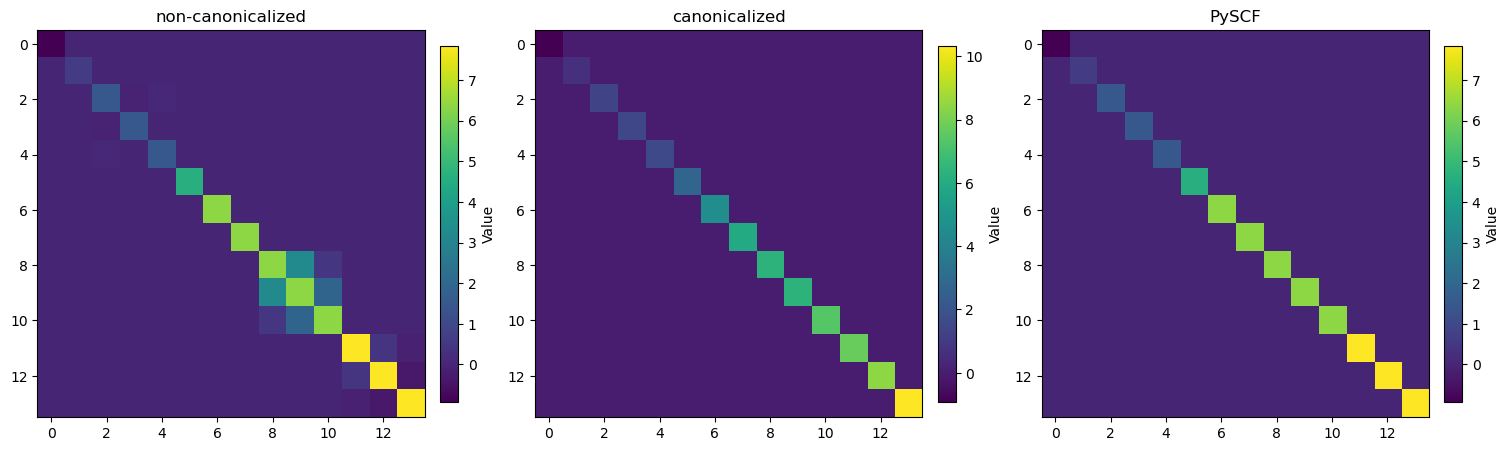

In [5]:
plot = _plot_3_maps_real(
    (F_MO_nc, F_MO_ca, F_MO_pyscf), titles=["non-canonicalized", "canonicalized", "PySCF"]
)

print(F_MO_nc[8:11, 8:11])

The solutions diagonalize the MO fock matrix, yes, but this is not fine. The degeneracy is broken. There is something going on here. It can be seen better in the next plot, where the lower bar shows the MO energies and shows that while PySCF's MO energies remain degenerate, the implementation ones do not. 

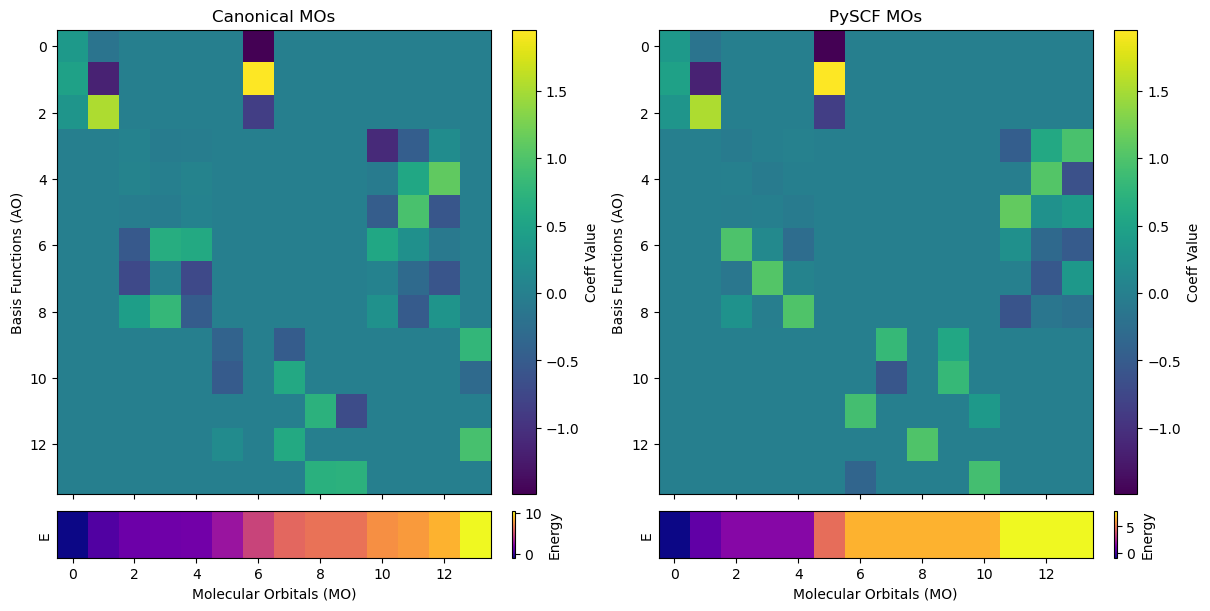

In [6]:
plot = plot_mo_analysis(
    C_ca, np.diag(F_MO_ca), mf.mo_coeff, mf.mo_energy, titles=["Canonical MOs", "PySCF MOs"]
)

So what can we get out of this: 
- Using the Pyscf solutions, they are shell degenerate, as expected.
- Using the canonicalized implementation solutions, they are not. 

Therefore in the building of the Fock matrix and/or densities we need to enforce somehow shell degeneracy. If not, we have the above matrix, where since the coefficients lead to a non-diagonal fock matrix by blocs, rotating them will result in the splitting of eigenvalues in that block as one expects in a regular matrix such as:
$$
\begin{pmatrix}
 6.35760442& 3.25777529& 0.46399747\\
 3.25777529& 6.35760442& 1.90233943\\
 0.46399747& 1.90233943& 6.35760442\\
\end{pmatrix}
$$
which is the case of part of the previous $d$ block, but diagonalizing results in a split of energies of the type $\varepsilon_i \approx \varepsilon_0 \pm c$. 

---


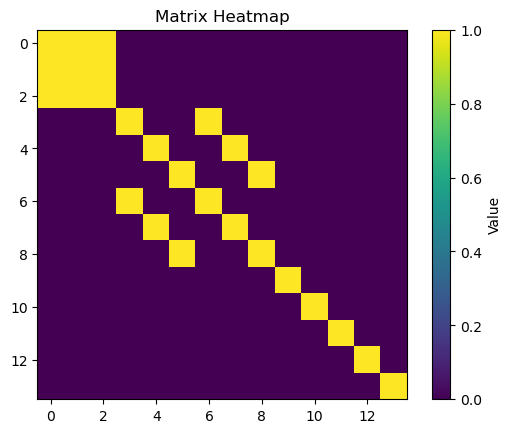

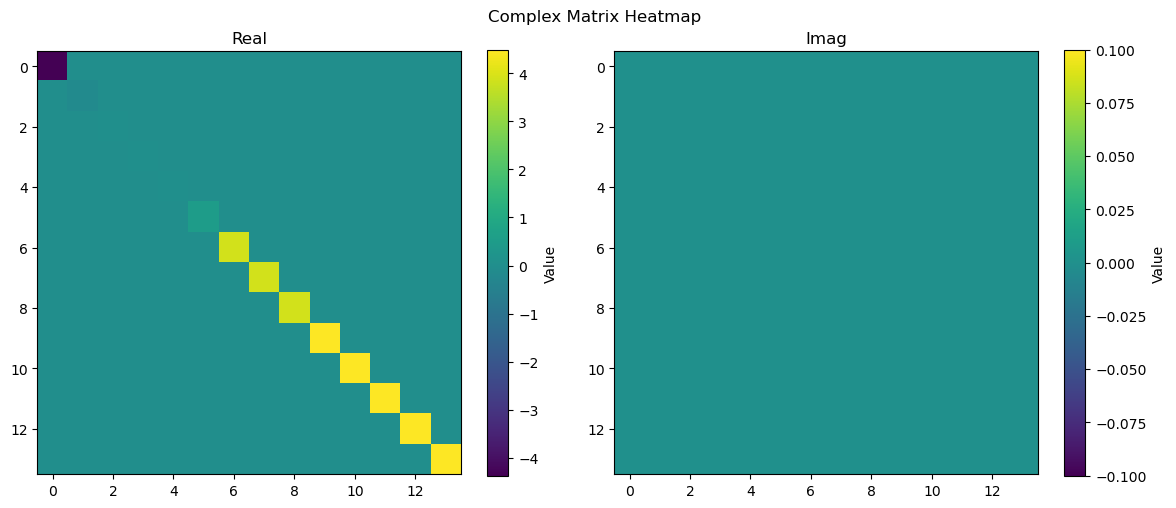

[-4.37535086 -0.14768385  0.04170491  0.04170491  0.04170491  0.52576998
  3.89866043  3.89866043  3.89866043  4.49144715  4.49144715  4.49144715
  4.49144715  4.49144715]


In [7]:
mask = np.abs(res.H_core) > 1e-10
mask = mask.astype(float)
plot_map( mask)

h_coreeigenval, h_core_eigenvec = np.linalg.eigh(res.H_core)

plot_map(h_core_eigenvec.T @ res.H_core @ h_core_eigenvec)

print(h_coreeigenval)

In [8]:
print(res.e_orb.real)

[-0.91762508  0.45319209  0.6366428   1.67429999  2.37404899  4.32297696
  4.60856321  5.37931102  5.80592278  6.35694731  7.33655495  8.39223189
  8.57677919  9.16237548]
